# Phần 1: Thông kê mô tả & đặc trưng

# 1.

In [15]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = sns.load_dataset("iris")
print (df.head())
print (df.shape)
print (df.dtypes)

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
(150, 5)
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species          object
dtype: object


## 2.

In [16]:
so = df.select_dtypes(include=[np.number])
danhsach = pd.DataFrame({
    'mean': so.mean(),
    'median': so.median(),
    'mode': so.mode().iloc[0],
    'var': so.var(),
    'std': so.std(),
    'min': so.min(),
    'max': so.max(),
    'Q1': so.quantile(0.25),
    'Q3': so.quantile(0.75)
})
danhsach['IQR'] = danhsach['Q3'] - danhsach['Q1']
print(danhsach.T)

        sepal_length  sepal_width  petal_length  petal_width
mean        5.843333     3.057333      3.758000     1.199333
median      5.800000     3.000000      4.350000     1.300000
mode        5.000000     3.000000      1.400000     0.200000
var         0.685694     0.189979      3.116278     0.581006
std         0.828066     0.435866      1.765298     0.762238
min         4.300000     2.000000      1.000000     0.100000
max         7.900000     4.400000      6.900000     2.500000
Q1          5.100000     2.800000      1.600000     0.300000
Q3          6.400000     3.300000      5.100000     1.800000
IQR         1.300000     0.500000      3.500000     1.500000


# 3.

In [17]:
dsnhom = df.groupby('species').agg(['mean', 'std'])

print(dsnhom.T)

species              setosa  versicolor  virginica
sepal_length mean  5.006000    5.936000   6.588000
             std   0.352490    0.516171   0.635880
sepal_width  mean  3.428000    2.770000   2.974000
             std   0.379064    0.313798   0.322497
petal_length mean  1.462000    4.260000   5.552000
             std   0.173664    0.469911   0.551895
petal_width  mean  0.246000    1.326000   2.026000
             std   0.105386    0.197753   0.274650


# Nhận xét về nhóm khác biệt rõ nhất:

Dựa trên đặc điểm của bộ dữ liệu Iris:

Nhóm Setosa là nhóm khác biệt rõ ràng nhất so với hai nhóm còn lại.

Vì khi nhìn vào giá trị trung bình của các thuộc tính, đặc biệt là petal_length và petal_width, loài Setosa có kích thước nhỏ hơn hẳn (petal_length trung bình khoảng 1.46, petal_width khoảng 0.24). Trong khi đó, hai loài Versicolor và Virginica có các chỉ số này lớn hơn và giá trị của chúng thường nằm sát nhau, khó phân tách hơn.

# Phần 2: Phân phối xác xuất

# 1.

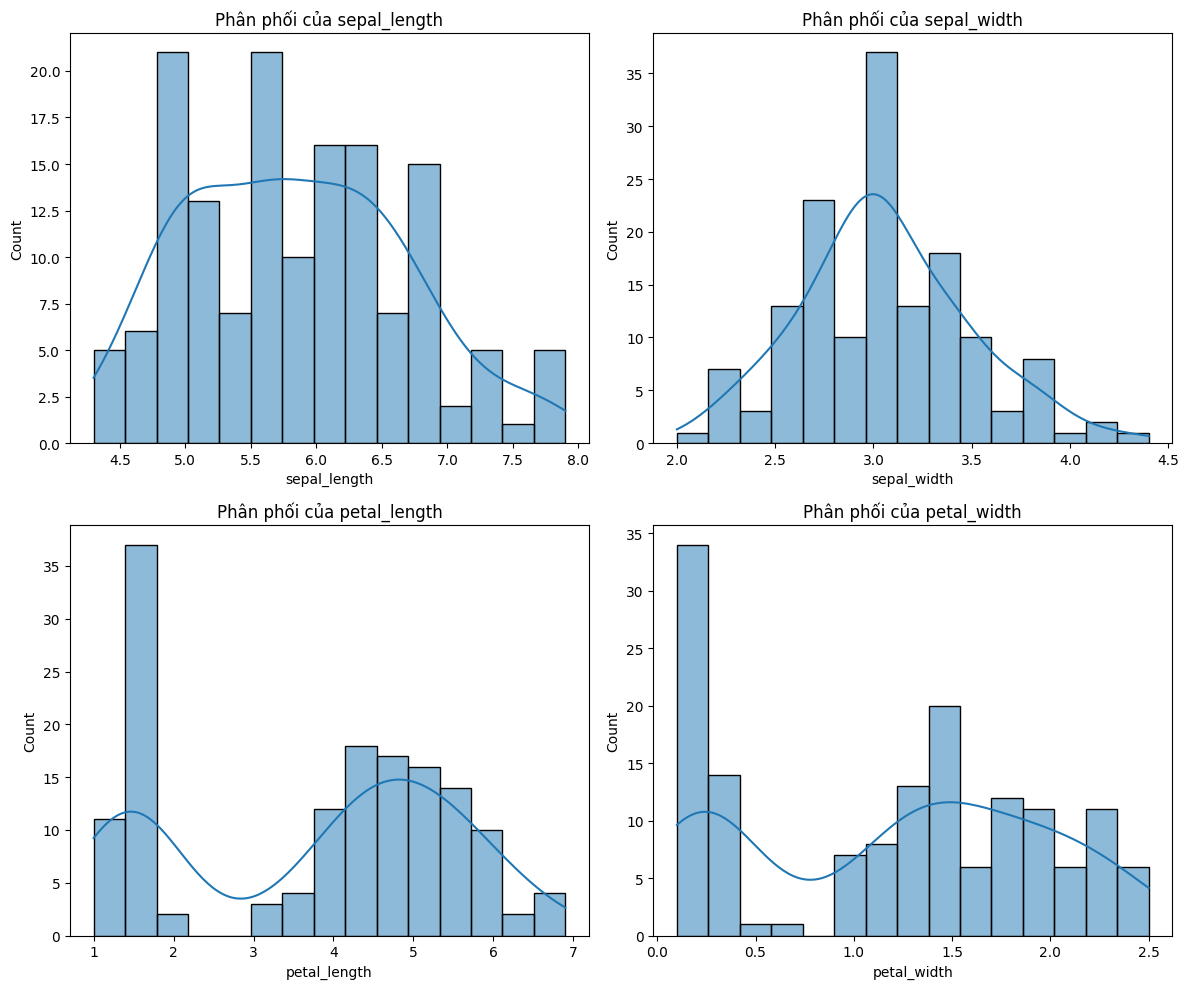

In [18]:
plt.figure(figsize=(12, 10))
for i, col in enumerate(so, 1):
    plt.subplot(2, 2, i)
    sns.histplot(data=df, x=col, kde=True, bins=15)
    plt.title(f'Phân phối của {col}')

plt.tight_layout()
plt.show()

Nhận xét hình dạng phân phối:

sepal_width: Có hình dáng giống quả chuông nhất, đối xứng quanh giá trị trung bình (khoảng 3.0). Nó rất gần với phân phối chuẩn.

sepal_length: Có vẻ hơi lệch phải.

petal_length & petal_width: Đây là phân phối nhiều đỉnh hai khối dữ liệu tách rời nhau. Nguyên nhân là do loài Setosa có cánh hoa rất nhỏ, tạo thành một đỉnh riêng biệt rớt lại phía bên trái của biểu đồ, trong khi hai loài còn lại tạo thành đỉnh lớn hơn bên phải.

# 2.

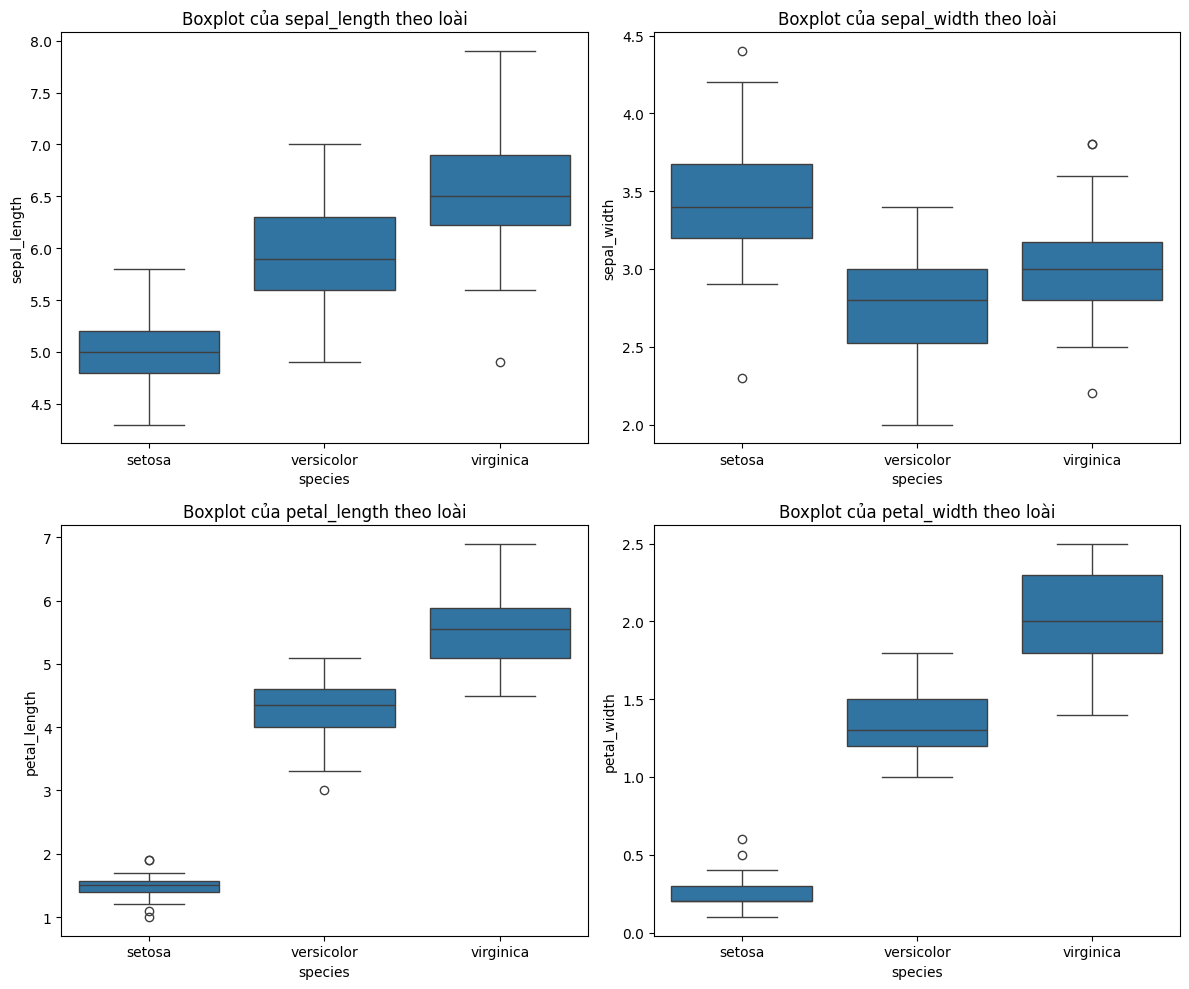

In [19]:
plt.figure(figsize=(12, 10))

for i, col in enumerate(so, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x='species', y=col)
    plt.title(f'Boxplot của {col} theo loài')

plt.tight_layout()
plt.show()

# 3.

Biến: sepal_width | Mean: 3.0573333333333337 | Std: 0.4358662849366982


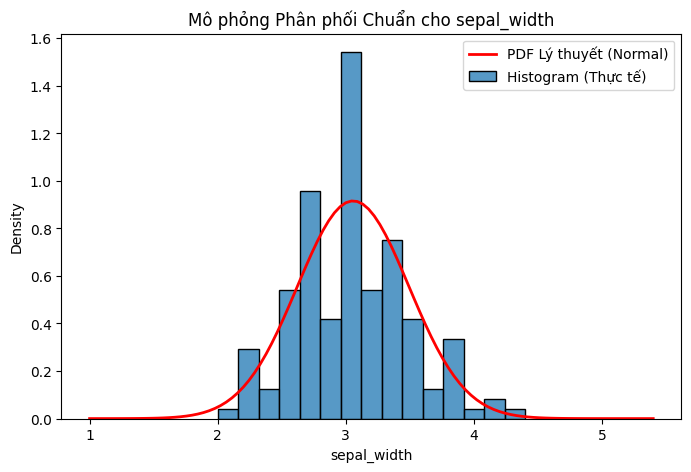

In [20]:
col = 'sepal_width'

mean = df[col].mean()
std = df[col].std()

print(f"Biến: {col} | Mean: {mean} | Std: {std}")
simulated_data = np.random.normal(mean, std, 1000)
plt.figure(figsize=(8, 5))

sns.histplot(df[col], stat='density', bins=15, label='Histogram (Thực tế)')

x_pdf = np.linspace(df[col].min() - 1, df[col].max() + 1, 100)
y_pdf = stats.norm.pdf(x_pdf, mean, std)
plt.plot(x_pdf, y_pdf, color='red', linewidth=2, label='PDF Lý thuyết (Normal)')

plt.title(f'Mô phỏng Phân phối Chuẩn cho {col}')
plt.legend()
plt.show()

Nhận xét mức độ khớp:

Nếu chạy đoạn mã trên với biến sepal_width, ta sẽ thấy các cột histogram thực tế bám sát theo đường cong cong màu đỏ (PDF lý thuyết). Điều này chứng tỏ mức độ khớp rất cao, và ta có thể giả định sepal_width tuân theo phân phối chuẩn.

# Phần 3: Phần tích đa biến & tương quan

# 1.

In [21]:

so = df.select_dtypes(include=[np.number])

print("MA TRẬN HIỆP PHƯƠNG SAI")
cov_matrix = so.cov()
print(cov_matrix)

print("\n MA TRẬN TƯƠNG QUAN")
corr_matrix = so.corr()
print(corr_matrix)

MA TRẬN HIỆP PHƯƠNG SAI
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      0.685694    -0.042434      1.274315     0.516271
sepal_width      -0.042434     0.189979     -0.329656    -0.121639
petal_length      1.274315    -0.329656      3.116278     1.295609
petal_width       0.516271    -0.121639      1.295609     0.581006

 MA TRẬN TƯƠNG QUAN
              sepal_length  sepal_width  petal_length  petal_width
sepal_length      1.000000    -0.117570      0.871754     0.817941
sepal_width      -0.117570     1.000000     -0.428440    -0.366126
petal_length      0.871754    -0.428440      1.000000     0.962865
petal_width       0.817941    -0.366126      0.962865     1.000000


# 2.

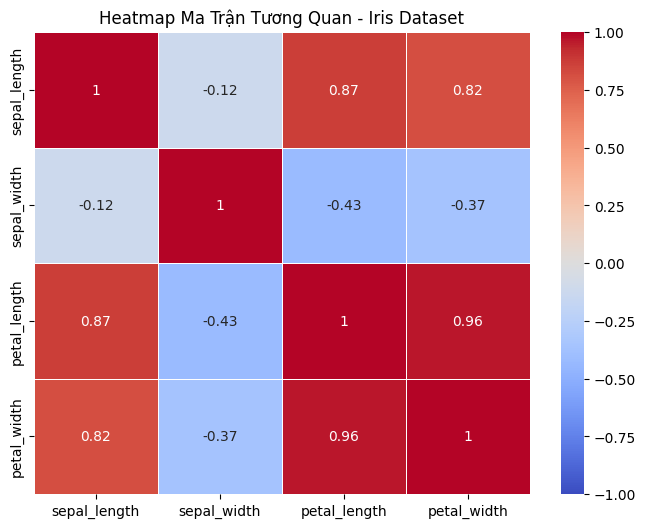

In [22]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,         
    cmap='coolwarm',
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title("Heatmap Ma Trận Tương Quan - Iris Dataset")
plt.show()

Nhận xét:

Cặp biến tương quan mạnh nhất: Dựa vào heatmap (ô màu đỏ đậm nhất), cặp biến petal_length và petal_width có độ tương quan dương mạnh nhất (r ≈ 0.96). Điều này có nghĩa là cánh hoa càng dài thì bề ngang cũng sẽ càng rộng. Kế đến là tương quan giữa sepal_length và petal_length (r ≈ 0.87).

CÓ dấu hiệu đa cộng tuyến. Đa cộng tuyến xảy ra khi hai hoặc nhiều biến độc lập trong mô hình có sự tương quan tuyến tính rất chặt chẽ với nhau. Việc petal_length và petal_width tương quan lên tới 0.96 cho thấy chúng đang cung cấp thông tin bị trùng lặp. Trong một số mô hình học máy, hiện tượng này có thể làm giảm độ tin cậy của mô hình.

# 3.

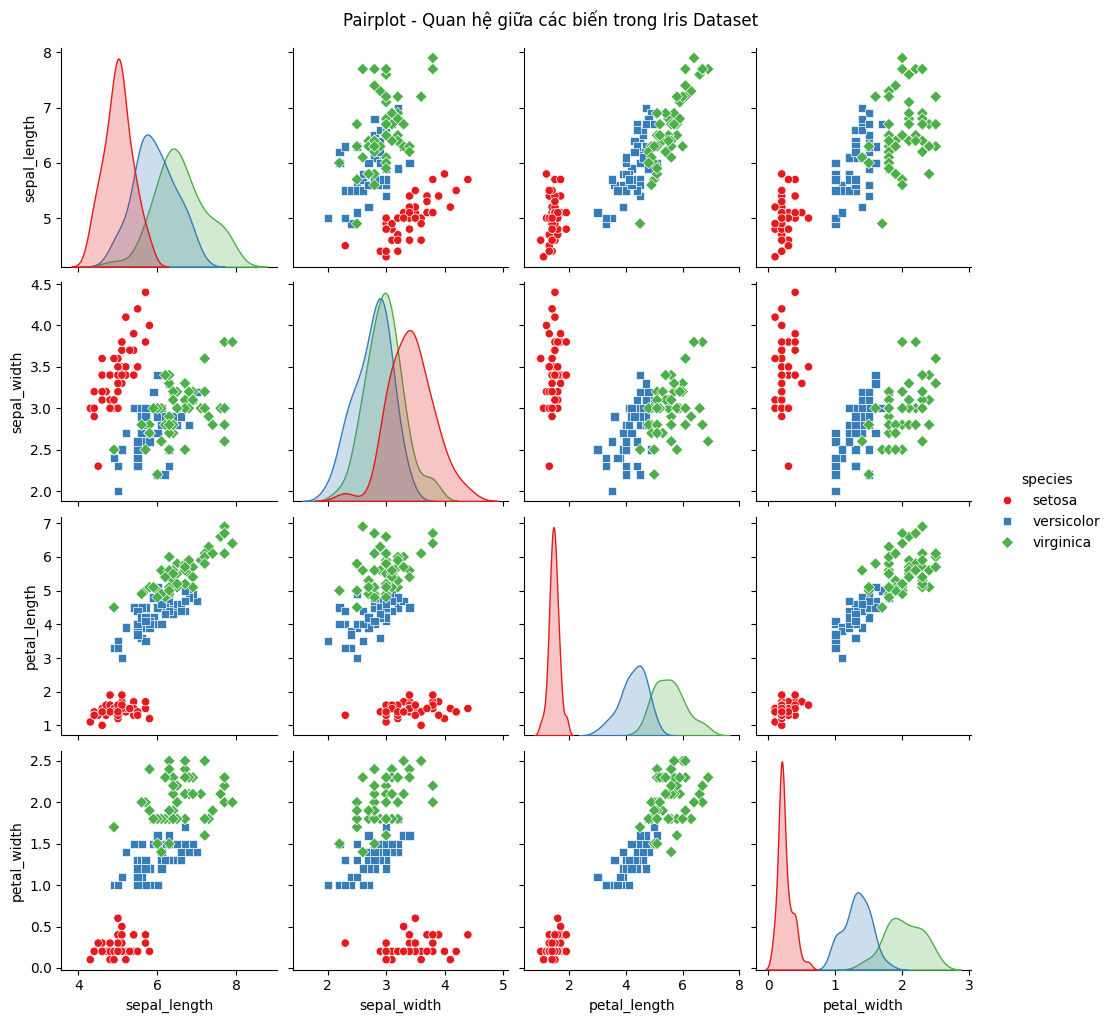

In [23]:
sns.pairplot(
    data=df,
    hue='species',
    palette='Set1',
    markers=["o", "s", "D"]
)

plt.suptitle("Pairplot - Quan hệ giữa các biến trong Iris Dataset", y = 1.02)
plt.show()

Nhận xét quan hệ giữa các biến:

Xu hướng tuyến tính rõ rệt: Ở các biểu đồ scatter plot giữa petal_length và petal_width, ta thấy các điểm dữ liệu xếp thành một đường chéo dốc lên rất rõ. Điều này củng cố lại kết luận về sự tương quan dương mạnh mẽ ở câu 2.

Khả năng phân tách nhóm : Nhóm hoa Setosa (màu đỏ) luôn nằm co cụm lại ở một góc riêng biệt trong hầu hết các biểu đồ. Điều này cho thấy nếu cần phân loại, Setosa là loài dễ nhận diện nhất.

Nhóm Versicolor và Virginica phân bố khá gần nhau, có một phần nhỏ chồng lấn. Tuy nhiên, nhìn chung Virginica có xu hướng dịch về phía góc phải trên so với Versicolor.

# Phần 4: Xác xuất và định lí Bayes

# 1.

In [24]:
P_B = 0.01
P_pos_given_B = 0.99
P_pos_given_NB = 0.05
P_NB = 1 - P_B

P_pos = (P_pos_given_B * P_B) + (P_pos_given_NB * P_NB)
P_B_given_pos = (P_pos_given_B * P_B) / P_pos
print(round(P_B_given_pos, 4))

0.1667


# 2.

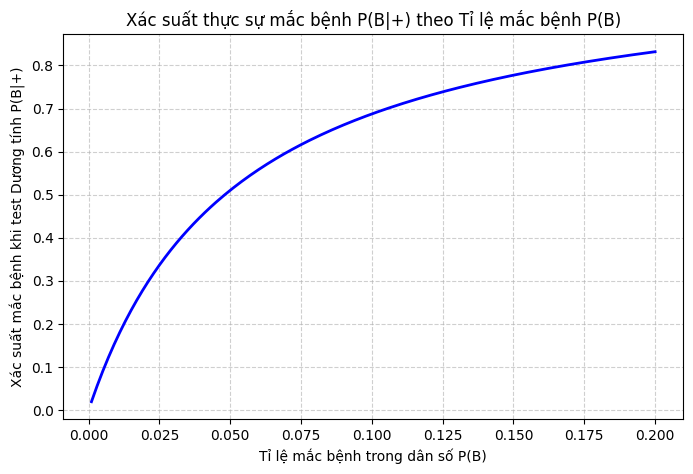

In [25]:
p_b_values = np.linspace(0.001, 0.2, 200)

p_pos_values = (P_pos_given_B * p_b_values) + (P_pos_given_NB * (1 - p_b_values))
p_b_given_pos_values = (P_pos_given_B * p_b_values) / p_pos_values

plt.figure(figsize=(8, 5))
plt.plot(p_b_values, p_b_given_pos_values, color='blue', linewidth=2)
plt.title('Xác suất thực sự mắc bệnh P(B|+) theo Tỉ lệ mắc bệnh P(B)')
plt.xlabel('Tỉ lệ mắc bệnh trong dân số P(B)')
plt.ylabel('Xác suất mắc bệnh khi test Dương tính P(B|+)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Giải thích sự phản trực giác:

Kết quả bài toán trên cho thấy: 

Dù xét nghiệm rất chính xác (độ nhạy 99%), nhưng khi cầm trên tay tờ kết quả dương tính, khả năng bạn thực sự mắc bệnh lại chỉ có ~16.6%.

Nguyên nhân là do căn bệnh này quá hiếm ($P(B) = 1\%$). Hãy tưởng tượng thử trên 10,000 người:

*  Chỉ có 100 người thực sự bệnh.
*  Xét nghiệm tìm ra 99 người (+).Có tới 9,900 người khỏe mạnh. Với tỉ lệ sai sót 5%, xét nghiệm sẽ báo nhầm tới $9,900 \times 0.05 = 495$ người (+).

Tổng cộng có $99 + 495 = 594$ người nhận kết quả dương tính, nhưng chỉ 99 người là thật. Do đó, tỉ lệ mắc bệnh thật sự chỉ là $\frac{99}{594} \approx 16.6\%$. Khi bệnh càng hiếm, số lượng dương tính giả lớn hơn nhiều so với số lượng dương tính thật, gây ra hiện tượng phản trực giác này.

# 3.Bonus

In [26]:
P_spam = 0.4
P_thg = 0.6

word_test = {
    'free':   {'Spam': 0.8, 'Thuong': 0.1},
    'money':  {'Spam': 0.7, 'Thuong': 0.2},
    'meeting':{'Spam': 0.1, 'Thuong': 0.8}
}

emails_to_test = [
    ['free', 'money'],
    ['meeting', 'free']
]

for i, email in enumerate(emails_to_test, 1):
    score_spam = P_spam
    for word in email:
        score_spam *= word_test[word]['Spam']

    score_thg = P_thg
    for word in email:
        score_thg *= word_test[word]['Thuong']

    P_is_spam = score_spam / (score_spam + score_thg)

    print(f"Email {i} {email}: Xác suất Spam = {P_is_spam*100:.2f}%")

Email 1 ['free', 'money']: Xác suất Spam = 94.92%
Email 2 ['meeting', 'free']: Xác suất Spam = 40.00%
